In [12]:
import random
import matplotlib.pyplot as plt
import numpy as np

In [1]:
# Fungsi untuk inisialisasi populasi
def inisialisasi_populasi(jumlah_populasi, jumlah_gen):
  populasi = []
  for i in range(jumlah_populasi):
    # Membuat kromosom dengan gen biner secara acak
    kromosom = [random.randint(0, 1) for _ in
    range(jumlah_gen)]
    populasi.append(kromosom)
  return populasi
# Contoh penggunaan
jumlah_populasi = 10 # Jumlah individu dalam populasi
jumlah_gen = 5 # Jumlah barang (gen) dalam kromosom

populasi_awal = inisialisasi_populasi(jumlah_populasi,
jumlah_gen)
# Menampilkan populasi awal
print("Populasi Awal:")
for idx, individu in enumerate(populasi_awal):
  print(f"Individu {idx+1}: {individu}")

Populasi Awal:
Individu 1: [0, 0, 0, 1, 1]
Individu 2: [0, 0, 0, 0, 0]
Individu 3: [1, 1, 1, 0, 1]
Individu 4: [1, 1, 1, 0, 0]
Individu 5: [0, 1, 0, 1, 0]
Individu 6: [1, 1, 1, 1, 1]
Individu 7: [0, 1, 0, 0, 0]
Individu 8: [1, 1, 1, 0, 1]
Individu 9: [1, 0, 1, 0, 1]
Individu 10: [1, 0, 0, 1, 0]


In [2]:
# Data barang (nama, harga, bobot)
barang = [
  ("Barang1", 60, 10),
  ("Barang2", 100, 20),
  ("Barang3", 120, 30),
  ("Barang4", 90, 25),
  ("Barang5", 70, 15)
]
kapasitas_tas = 50 # Kapasitas maksimum tas
# Fungsi untuk menghitung nilai fitness
def hitung_fitness(kromosom, barang, kapasitas_tas):
  total_harga = 0
  total_bobot = 0
  for i in range(len(kromosom)):
    if kromosom[i] == 1:
      total_harga += barang[i][1]
      total_bobot += barang[i][2]
  if total_bobot > kapasitas_tas:
    return 0 # Penalti jika melebihi kapasitas
  else:
    return total_harga

# Definisi contoh populasi awal
populasi_awal = [
  [1, 0, 1, 0, 1], # Contoh kromosom individu
  [0, 1, 0, 1, 0],
  [1, 1, 0, 0, 1],
  # Tambahkan lebih banyak individu sesuai kebutuhan
]
# Contoh penggunaan
fitness_populasi = [hitung_fitness(individu, barang,
kapasitas_tas) for individu in populasi_awal]
# Menampilkan nilai fitness
print("\nNilai Fitness:")
for idx, fitness in enumerate(fitness_populasi):
  print(f"Individu {idx+1}: Fitness = {fitness}")



Nilai Fitness:
Individu 1: Fitness = 0
Individu 2: Fitness = 190
Individu 3: Fitness = 230


In [5]:
# Fungsi untuk Roulette Wheel Selection
def roulette_wheel_selection(populasi, fitness_populasi):
  total_fitness = sum(fitness_populasi)
  if total_fitness == 0:
    idx = random.randrange(len(populasi))
    return populasi[idx], idx # Mengembalikan individu dan indeksnya
  probabilitas = [fitness / total_fitness for fitness in fitness_populasi]
  kumulatif_prob = []
  kumulatif = 0
  for p in probabilitas:
    kumulatif += p
    kumulatif_prob.append(kumulatif)
  r = random.random()
  for i, kum_prob in enumerate(kumulatif_prob):
    if r <= kum_prob:
      return populasi[i], i # Mengembalikan individu indeksnya
  return populasi[-1], len(populasi)-1 # Jika tidak ada yang memenuhi, kembalikan individu terakhir
# Fungsi untuk Tournament Selection
def tournament_selection(populasi, fitness_populasi, k=3):
  if len(populasi) < k:
    k = len(populasi)
  peserta_indices = random.sample(range(len(populasi)), k)
  peserta = [(populasi[i], fitness_populasi[i], i) for i in
  peserta_indices]
  peserta.sort(key=lambda x: x[1], reverse=True)
  return peserta[0][0], peserta[0][2] # Mengembalikan individu dan indeksnya

# Definisikan populasi awal dan fitness_populasi
populasi_awal = ['individu1', 'individu2', 'individu3', 'individu4']
fitness_populasi = [10, 20, 30, 40]
# Membuat salinan populasi dan fitness untuk dimodifikasi
available_populasi = populasi_awal.copy()
available_fitness = fitness_populasi.copy()
# Contoh penggunaan
# Memilih Parent 1 menggunakan Roulette Wheel Selection
parent1, idx1 = roulette_wheel_selection(available_populasi, available_fitness)
# Menghapus parent1 dari daftar available_populasi dan
available_fitness
del available_populasi[idx1]
del available_fitness[idx1]
# Memilih Parent 2 menggunakan Tournament Selection
parent2, idx2 = tournament_selection(available_populasi, available_fitness)
# Menghapus parent2 dari daftar available_populasi dan available_fitness
del available_populasi[idx2]
del available_fitness[idx2]
print("\nParent Terpilih:")
print(f"Parent 1: {parent1}")
print(f"Parent 2: {parent2}")



Parent Terpilih:
Parent 1: individu4
Parent 2: individu3


In [7]:
# One-Point Crossover
def one_point_crossover(parent1, parent2):
  titik_potong = random.randint(1, len(parent1)-1)
  anak1 = parent1[:titik_potong] + parent2[titik_potong:]
  anak2 = parent2[:titik_potong] + parent1[titik_potong:]
  return anak1, anak2
# Two-Point Crossover
def two_point_crossover(parent1, parent2):
  titik1 = random.randint(1, len(parent1)-2)
  titik2 = random.randint(titik1+1, len(parent1)-1)
  anak1 = parent1[:titik1] + parent2[titik1:titik2] + parent1[titik2:]
  anak2 = parent2[:titik1] + parent1[titik1:titik2] + parent2[titik2:]
  return anak1, anak2
# Uniform Crossover
def uniform_crossover(parent1, parent2):
  # Membuat mask acak
  mask = [random.randint(0, 1) for _ in
  range(len(parent1))]
  anak1 = []
  anak2 = []
  for i in range(len(parent1)):
    if mask[i] == 0:
    # Jika mask bernilai 0, ambil gen dari parent1 untuk anak1, dan parent2 untuk anak2
      anak1.append(parent1[i])
      anak2.append(parent2[i])
    else:
    # Jika mask bernilai 1, ambil gen dari parent2 untuk anak1, dan parent1 untuk anak2
      anak1.append(parent2[i])
      anak2.append(parent1[i])
  return anak1, anak2
# Contoh penggunaan
parent1 = [1, 0, 1, 1, 0] # Contoh parent1
parent2 = [0, 1, 0, 0, 1] # Contoh parent2
anak1, anak2 = one_point_crossover(parent1, parent2)
print("\nAnak Hasil Crossover:")
print(f"Anak 1: {anak1}")
print(f"Anak 2: {anak2}")



Anak Hasil Crossover:
Anak 1: [1, 0, 1, 1, 1]
Anak 2: [0, 1, 0, 0, 0]


In [11]:
# Swap Mutation
def swap_mutation(kromosom):
  # Pastikan kromosom adalah list
  kromosom = list(kromosom) # Konversi ke list jika perlu
  # Pilih dua posisi untuk swap
  posisi1, posisi2 = random.sample(range(len(kromosom)), 2)
  # Melakukan swap
  kromosom[posisi1], kromosom[posisi2] = kromosom[posisi2], kromosom[posisi1]
  return kromosom
# Inversion Mutation
def inversion_mutation(kromosom):
  posisi1 = random.randint(0, len(kromosom) - 2)
  posisi2 = random.randint(posisi1 + 1, len(kromosom) - 1)
  # Perbaikan di sini: konversi hasil reversed ke list
  kromosom[posisi1:posisi2] = list(reversed(kromosom[posisi1:posisi2]))
  return kromosom
# Uniform Mutation
def uniform_mutation(kromosom, mutation_rate=0.1):
  # Pastikan kromosom adalah list
  kromosom = list(kromosom) # Konversi ke list jika perlu
  for i in range(len(kromosom)):
    if random.random() < mutation_rate:
      kromosom[i] = 1 - kromosom[i] # Membalik nilai gen
  return kromosom
# Definisikan anak1 sebelum digunakan
anak1 = [0, 1, 1, 0, 1] # Contoh kromosom, sesuaikan dengan kebutuhan Anda
# Contoh penggunaan
mutasi_anak1 = swap_mutation(anak1.copy()) # Swap Mutation
mutasi_anak2 = inversion_mutation(anak1.copy()) # Inversion Mutation
mutasi_anak3 = uniform_mutation(anak1.copy()) # Uniform Mutation
# Menampilkan hasil setelah mutasi
print("\nAnak Setelah Mutasi:")
print(f"Anak 1 (Swap Mutation): {mutasi_anak1}")
print(f"Anak 2 (Inversion Mutation): {mutasi_anak2}")
print(f"Anak 3 (Uniform Mutation): {mutasi_anak3}")



Anak Setelah Mutasi:
Anak 1 (Swap Mutation): [0, 1, 1, 0, 1]
Anak 2 (Inversion Mutation): [1, 1, 0, 0, 1]
Anak 3 (Uniform Mutation): [0, 1, 1, 0, 0]


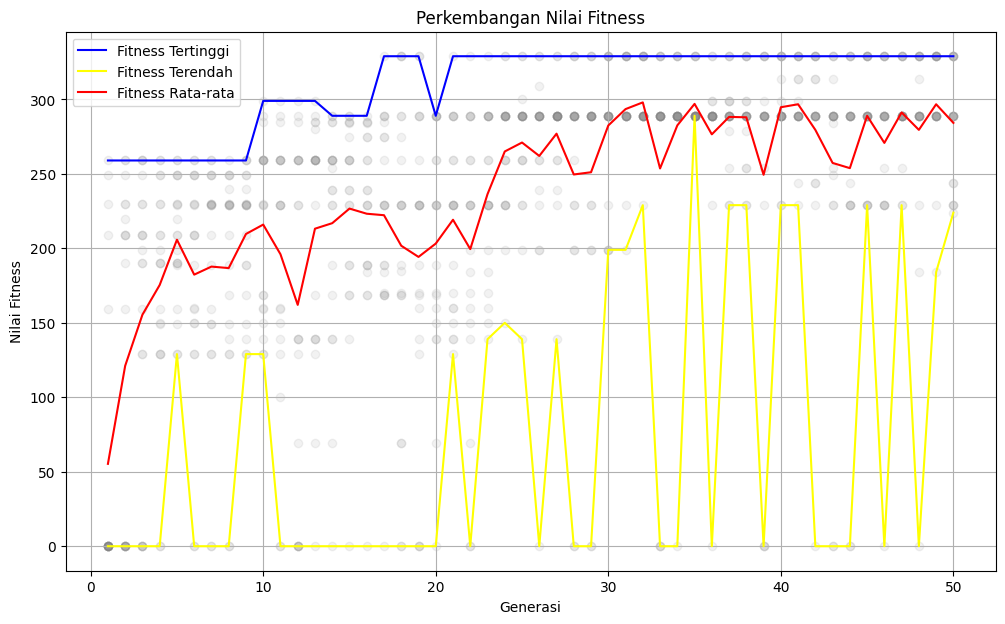

Nilai Fitness Terbaik: 329
Total Bobot: 50
Barang Terpilih:
- Barang2
- Barang5
- Barang6
- Barang8
Nilai Fitness Terbaik: 329
Total Bobot: 50
Barang Terpilih:
- Barang2
- Barang5
- Barang6
- Barang8


In [21]:
# Data barang: (nama, nilai, berat)
barang = [
  ("Barang1", 60, 10),
  ("Barang2", 100, 20),
  ("Barang3", 120, 30),
  ("Barang4", 90, 25),
  ("Barang5", 69, 11),
  ("Barang6", 70, 9),
  ("Barang7", 80, 15),
  ("Barang8", 90, 10),
  ("Barang9", 25, 3)
]
def run_ga(jumlah_generasi, jumlah_populasi, prob_crossover, prob_mutasi, kapasitas_tas):
  # Menentukan jumlah gen berdasarkan jumlah barang
  jumlah_gen = len(barang)
  # Inisialisasi populasi awal
  populasi = inisialisasi_populasi(jumlah_populasi, jumlah_gen)
  # Menghitung fitness untuk setiap individu dalam populasi
  fitness_populasi = [hitung_fitness(individu, barang, kapasitas_tas) for individu in populasi]
  # List untuk menyimpan nilai fitness terbaik, terburuk, dan rata-rata setiap generasi
  best_fitness_list = []
  worst_fitness_list = []
  avg_fitness_list = []
  all_fitness = []
  # Variabel untuk menyimpan individu terbaik secara keseluruhan
  best_individu = None
  best_fitness_overall = 0
  # Proses evolusi selama jumlah generasi yang ditentukan
  for generasi in range(jumlah_generasi):
    # Evaluasi fitness populasi saat ini
    fitness_populasi = [hitung_fitness(individu, barang, kapasitas_tas) for individu in populasi]
    # Menyimpan nilai fitness untuk plotting
    best_fitness = max(fitness_populasi)
    worst_fitness = min(fitness_populasi)
    avg_fitness = sum(fitness_populasi) / len(fitness_populasi)
    best_fitness_list.append(best_fitness)
    worst_fitness_list.append(worst_fitness)
    avg_fitness_list.append(avg_fitness)
    all_fitness.append(fitness_populasi.copy())
    # Menyimpan individu terbaik secara keseluruhan
    if best_fitness > best_fitness_overall:
      best_fitness_overall = best_fitness
      index_best = fitness_populasi.index(best_fitness)
      best_individu = populasi[index_best]
    new_populasi = []
    used_indices = []
    # Membentuk populasi baru
    while len(new_populasi) < jumlah_populasi:
      # Seleksi orang tua menggunakan roulette wheel
      parent1, idx1 = roulette_wheel_selection(populasi, fitness_populasi)
      used_indices.append(idx1)
      # Memastikan orang tua kedua berbeda
      available_indices = [i for i in range(len(populasi)) if i not in
      used_indices]
      if not available_indices:
        used_indices = [idx1]
        available_indices = [i for i in range(len(populasi)) if i !=
        idx1]
      parent2, _ = roulette_wheel_selection([populasi[i] for i in available_indices],[fitness_populasi[i] for i in available_indices])
      used_indices.append(available_indices[_])
      # Crossover untuk menghasilkan anak
      if random.random() < prob_crossover:
        anak1, anak2 = one_point_crossover(parent1, parent2)
      else:
        anak1, anak2 = parent1[:], parent2[:]
      # Mutasi pada anak
      if random.random() < prob_mutasi:
        anak1 = swap_mutation(anak1)
      if random.random() < prob_mutasi:
        anak2 = swap_mutation(anak2)
      # Menambahkan anak ke populasi baru
      new_populasi.extend([anak1, anak2])
    # Memastikan populasi baru sesuai dengan jumlah populasi
    populasi = new_populasi[:jumlah_populasi]
  # Menampilkan grafik fitness
  plt.figure(figsize=(12, 7))
  # Plot semua nilai fitness dengan transparansi rendah
  for i in range(jumlah_generasi):
    x = [i+1]*len(all_fitness[i])
    y = all_fitness[i]
    plt.scatter(x, y, color='gray', alpha=0.1)
  # Plot nilai fitness terbaik, terburuk, dan rata-rata
  plt.plot(range(1, jumlah_generasi+1), best_fitness_list, color='blue', label='Fitness Tertinggi')
  plt.plot(range(1, jumlah_generasi+1), worst_fitness_list, color='yellow',
  label='Fitness Terendah')
  plt.plot(range(1, jumlah_generasi+1), avg_fitness_list, color='red',
  label='Fitness Rata-rata')
  plt.title('Perkembangan Nilai Fitness')
  plt.xlabel('Generasi')
  plt.ylabel('Nilai Fitness')
  plt.legend()
  plt.grid(True)
  plt.show()
  # Menampilkan barang yang terpilih dalam knapsack terbaik
  selected_items = [barang[i][0] for i in range(len(best_individu)) if
  best_individu[i] == 1]
  selected_value = hitung_fitness(best_individu, barang, kapasitas_tas)
  selected_weight = sum([barang[i][2] for i in range(len(best_individu)) if
  best_individu[i] == 1])
  print(f"Nilai Fitness Terbaik: {selected_value}")
  print(f"Total Bobot: {selected_weight}")
  print("Barang Terpilih:")
  for item in selected_items:
    print(f"- {item}")
  populasi = inisialisasi_populasi(jumlah_populasi, jumlah_gen)
  fitness_populasi = [hitung_fitness(individu, barang, kapasitas_tas) for individu in populasi]
  parent1, idx1 = roulette_wheel_selection(populasi, fitness_populasi)
  parent2, _ = roulette_wheel_selection([populasi[i] for i in available_indices], [fitness_populasi[i] for i in available_indices])
  if random.random() < prob_crossover:
    anak1, anak2 = one_point_crossover(parent1, parent2)
  else:
    anak1, anak2 = parent1[:], parent2[:]
  if random.random() < prob_mutasi:
    anak1 = swap_mutation(anak1)
  if random.random() < prob_mutasi:
    anak2 = swap_mutation(anak2)
  new_populasi.extend([anak1, anak2])
  populasi = new_populasi[:jumlah_populasi]
  selected_items = [barang[i][0] for i in range(len(best_individu)) if best_individu[i] == 1]
  selected_value = hitung_fitness(best_individu, barang, kapasitas_tas)
  selected_weight = sum([barang[i][2] for i in range(len(best_individu)) if best_individu[i] == 1])
  print(f"Nilai Fitness Terbaik: {selected_value}")
  print(f"Total Bobot: {selected_weight}")
  print("Barang Terpilih:")
  for item in selected_items:
    print(f"- {item}")

# Menjalankan GA dengan parameter berikut
run_ga(
  jumlah_generasi=50,
  jumlah_populasi=20,
  prob_crossover=0.5,
  prob_mutasi=0.1,
  kapasitas_tas=50
)


NameError: name 'available_indices' is not defined